In [10]:
from matplotlib import pyplot as plt
import seaborn as sns

from skimage.metrics import structural_similarity as ssim
from skimage.measure import regionprops_table
from skimage import io
from csbdeep.utils import normalize

from scipy.stats import levene,f_oneway,kruskal,tukey_hsd

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ConfIntSampler

import numpy as np
import pandas as pd
from glob import glob

import warnings
warnings.filterwarnings('ignore')

In [12]:
basedir = '/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig3/Deconvolution_measurements/'

### Read the image crops
crops = sorted(glob(f'/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig3/Deconvolution_measurements/SSIM_crops/*.tif'))
crops = [io.imread(crop) for crop in crops]

In [13]:
crops_softworx = [normalize(crop[:,:,0]) for crop in crops]
crops_fp2fm = [normalize(crop[:,:,2]) for crop in crops]

In [14]:
FP2FM_ssim = [ssim(x, y, data_range=y.max() - y.min()) for x,y in zip(crops_softworx,crops_fp2fm)]

df = pd.DataFrame()
df.insert(0,'SSIM',FP2FM_ssim)
df.insert(0,'Target','FP2FM')

df.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS6_SSIM.csv')

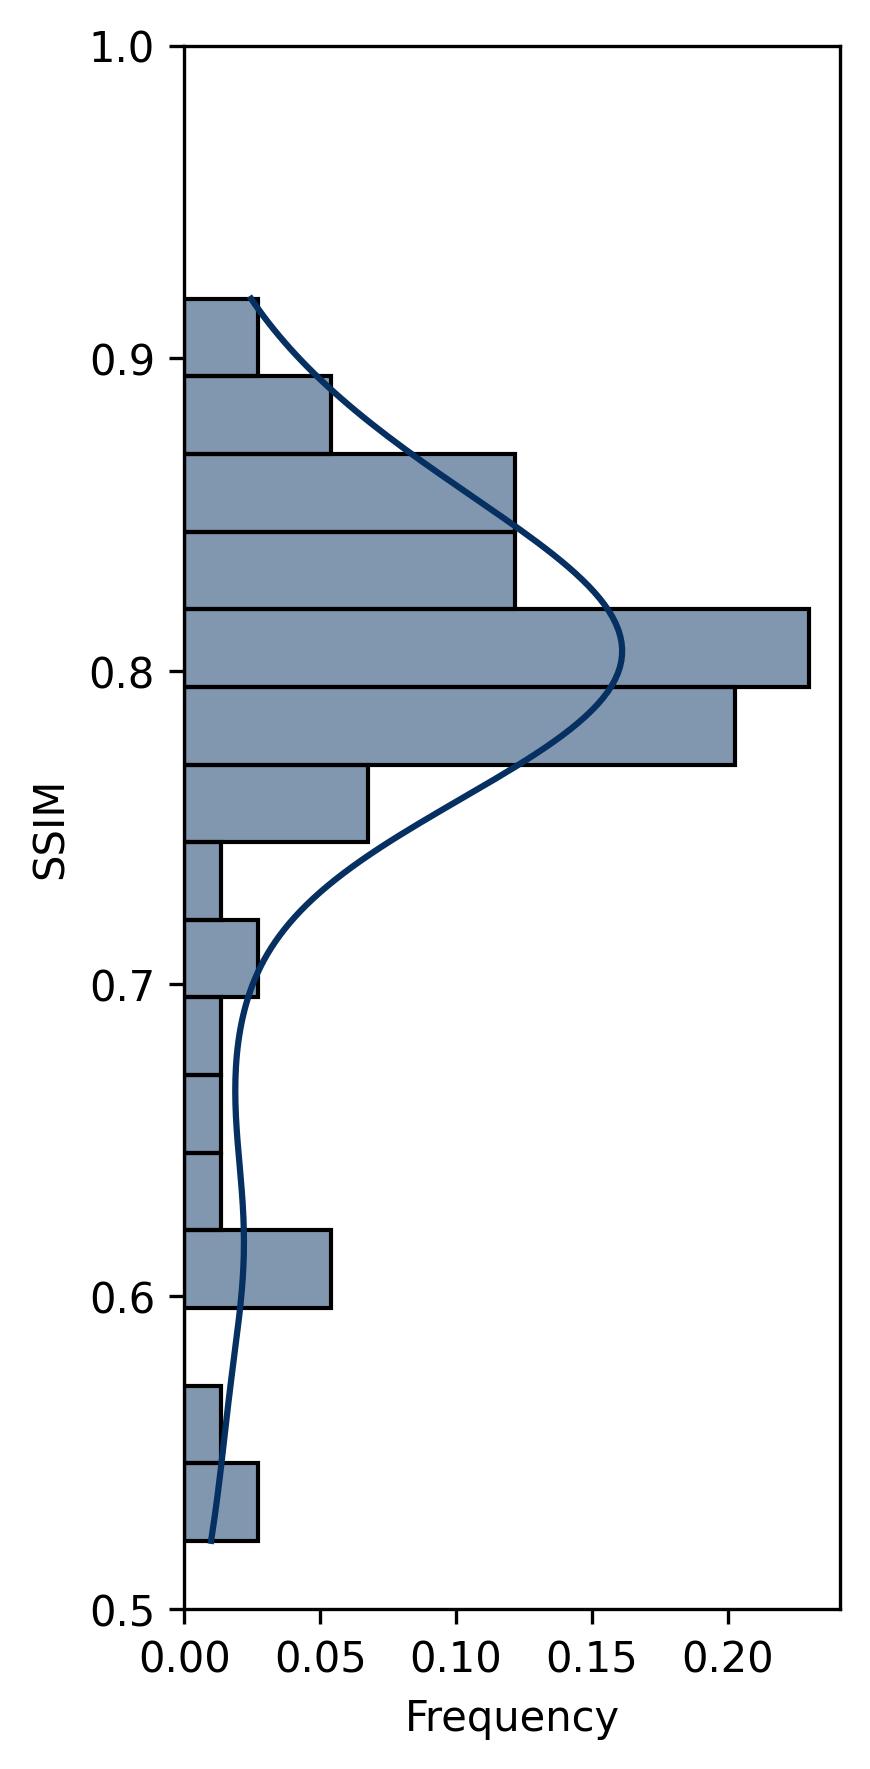

In [32]:
df = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS6_SSIM.csv')

fig,ax = plt.subplots(dpi=300,figsize=(3,6))

sns.histplot(data=df,y='SSIM',ax=ax,color='#053061',kde=True,alpha=0.5,stat='probability')
ax.set_ylabel('SSIM')
ax.set_xlabel('Frequency')
ax.set_ylim(0.5,1)

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS6/SSIM_FP2FM.png')

In [19]:
masks_softworx = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig3/Deconvolution_measurements/SoftWorx/*.tif'))

masks_FP2FM = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig3/Deconvolution_measurements/FP2FM/*.tif'))

assert len(masks_softworx) == len(masks_FP2FM)

print(len(masks_softworx))

all_masks = [masks_softworx,masks_FP2FM]

methods = ['SoftWorx','FP2FM']

dfs = [SizeDataFrame(masks) for masks in all_masks]

for df,method in zip(dfs,methods):
    df.insert(0,'Method',method)

dfs = pd.concat(dfs,ignore_index=True)


20


In [20]:

dfs = dfs[dfs['Width'] > 0.3]
dfs = dfs[dfs['Width'] < 1.5]

softworx = dfs[dfs['Method'] == 'SoftWorx']
FP2FM = dfs[dfs['Method'] == 'FP2FM']

print(len(softworx),len(FP2FM))

metrics = ['Width','Length','SurfaceArea','Volume']

sampled_dfs = []

for metric in metrics:

    sampled_dfs.append(ConfIntSampler(df=dfs,columns=['Method'],metric=metric)[['Method',metric]])

1047 1077


In [23]:
softworx_props = [pd.DataFrame(regionprops_table(io.imread(mask),properties=['area','eccentricity','solidity','area_convex'])) for mask in masks_softworx]
softworx_props = pd.concat(softworx_props,ignore_index=True)
softworx_props.insert(0,'Method','SoftWorx')

FP2FM_props = [pd.DataFrame(regionprops_table(io.imread(mask),properties=['area','eccentricity','solidity','area_convex'])) for mask in masks_FP2FM]
FP2FM_props = pd.concat(FP2FM_props,ignore_index=True)
FP2FM_props.insert(0,'Method','FP2FM')

In [24]:
joint_df = pd.concat([softworx_props,FP2FM_props])
pixsize = 33.02/512
order = ['SoftWorx','FP2FM']

joint_df['area'] = joint_df['area']*pixsize*pixsize
joint_df['area_convex'] = joint_df['area_convex']*pixsize*pixsize

aa = ConfIntSampler(joint_df,['Method'],'area')
ac = ConfIntSampler(joint_df,['Method'],'area_convex')
ecc = ConfIntSampler(joint_df,['Method'],'eccentricity')
sol = ConfIntSampler(joint_df,['Method'],'solidity')

In [25]:
sampled_dfs.append(aa)
sampled_dfs.append(ac)
sampled_dfs.append(ecc)
sampled_dfs.append(sol)

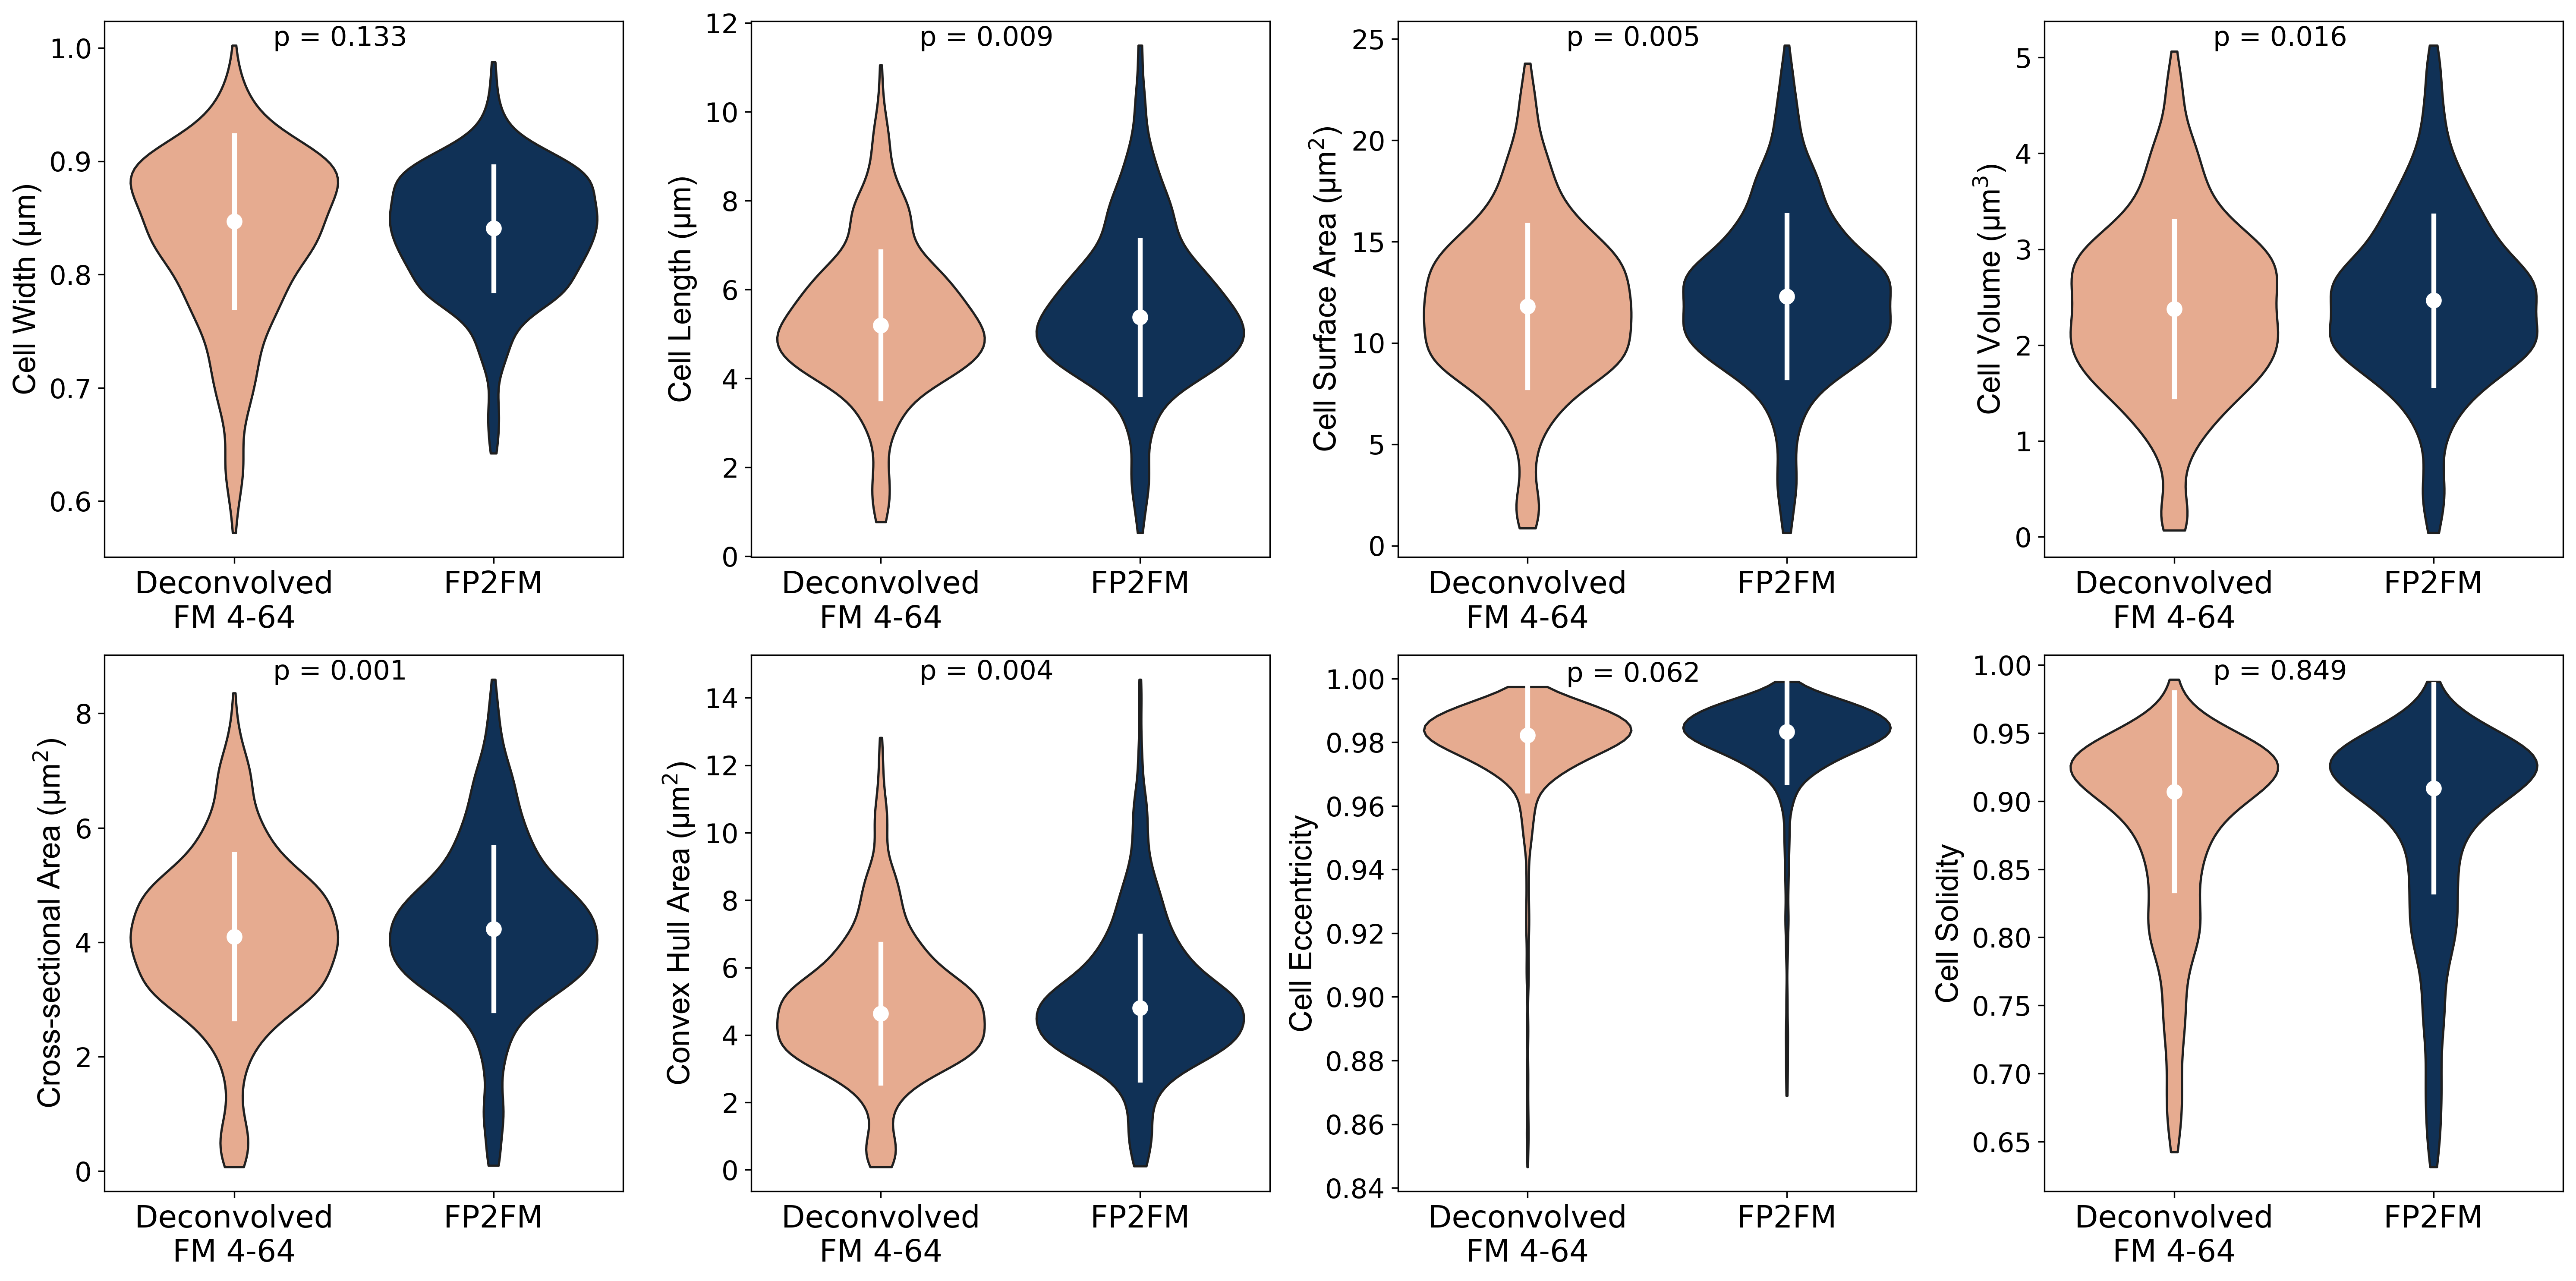

In [27]:
colors = ['#053061','#f4a582']#SoftWorx, FP2FM

metrics = ['Width','Length','SurfaceArea','Volume','area','area_convex','eccentricity','solidity']

fig,ax = plt.subplots(dpi=300,figsize=(20,10),ncols=4,nrows=2)
ax = ax.flatten()

labels = [f'Deconvolved\nFM 4-64','FP2FM']

for i,subdf in enumerate(sampled_dfs):

    metric = metrics[i]
    
    fp2fm = np.array(subdf[subdf['Method'] == 'FP2FM'][metric])
    softworx = np.array(subdf[subdf['Method'] == 'SoftWorx'][metric])
    
    if levene(fp2fm,softworx)[1] > 0.05:
        pval = f_oneway(fp2fm,softworx)[1]
    else:
        pval = kruskal(fp2fm,softworx)[1]
        
    ### Prepare axis label and title

    if metric == 'SurfaceArea':
        ylab = 'Cell Surface Area (µm$^2$)'
        
    elif metric == 'Volume':
        ylab = 'Cell Volume (µm$^3$)'

    elif metric == 'Width':
        ylab = f'Cell {metric} (µm)'

    elif metric == 'Length':
        ylab = f'Cell {metric} (µm)'

    elif metric == 'area':
        ylab = 'Cross-sectional Area (µm$^2$)'
        
    elif metric == 'area_convex':
        ylab = 'Convex Hull Area (µm$^2$)'

    else:
        ylab = f'Cell {metric.capitalize()}'
    
    sns.violinplot(data=subdf,x='Method',y=metric,ax=ax[i],order=['SoftWorx', 'FP2FM'],hue='Method',cut=0,inner=None,palette=colors,density_norm='area')
    sns.pointplot(data=subdf,x='Method',y=metric,ax=ax[i],order=['SoftWorx', 'FP2FM'],linestyle='none',color='w',errorbar='sd',estimator='median')
    ax[i].text(0.15,np.max(subdf[metric]),f'p = {pval:.3f}',fontsize=15)
    
    ax[i].set_xticklabels(labels,fontsize=17)
    ax[i].set_ylabel(ylab,fontname='Arial',fontsize=17)
    ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=15)
    ax[i].set_xlabel('')
    
fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS6/Violins_revision_FP2FM.png')

In [28]:
metrics = ['Width','Length','SurfaceArea','Volume','area','area_convex','eccentricity','solidity']

for df,metric in zip(sampled_dfs,metrics):

    df.to_csv(f'/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS6_{metric}.csv')

In [33]:
metrics = ['Width','Length','SurfaceArea','Volume','area','area_convex','eccentricity','solidity']

w = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_Width.csv')
L = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_Length.csv')
S = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_SurfaceArea.csv')
V = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_Volume.csv')
aa = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_area.csv')
ac = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_area_convex.csv')
ecc = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_eccentricity.csv')
sol = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS6_solidity.csv')

sampled_dfs = [w,L,S,V,aa,ac,ecc,sol]

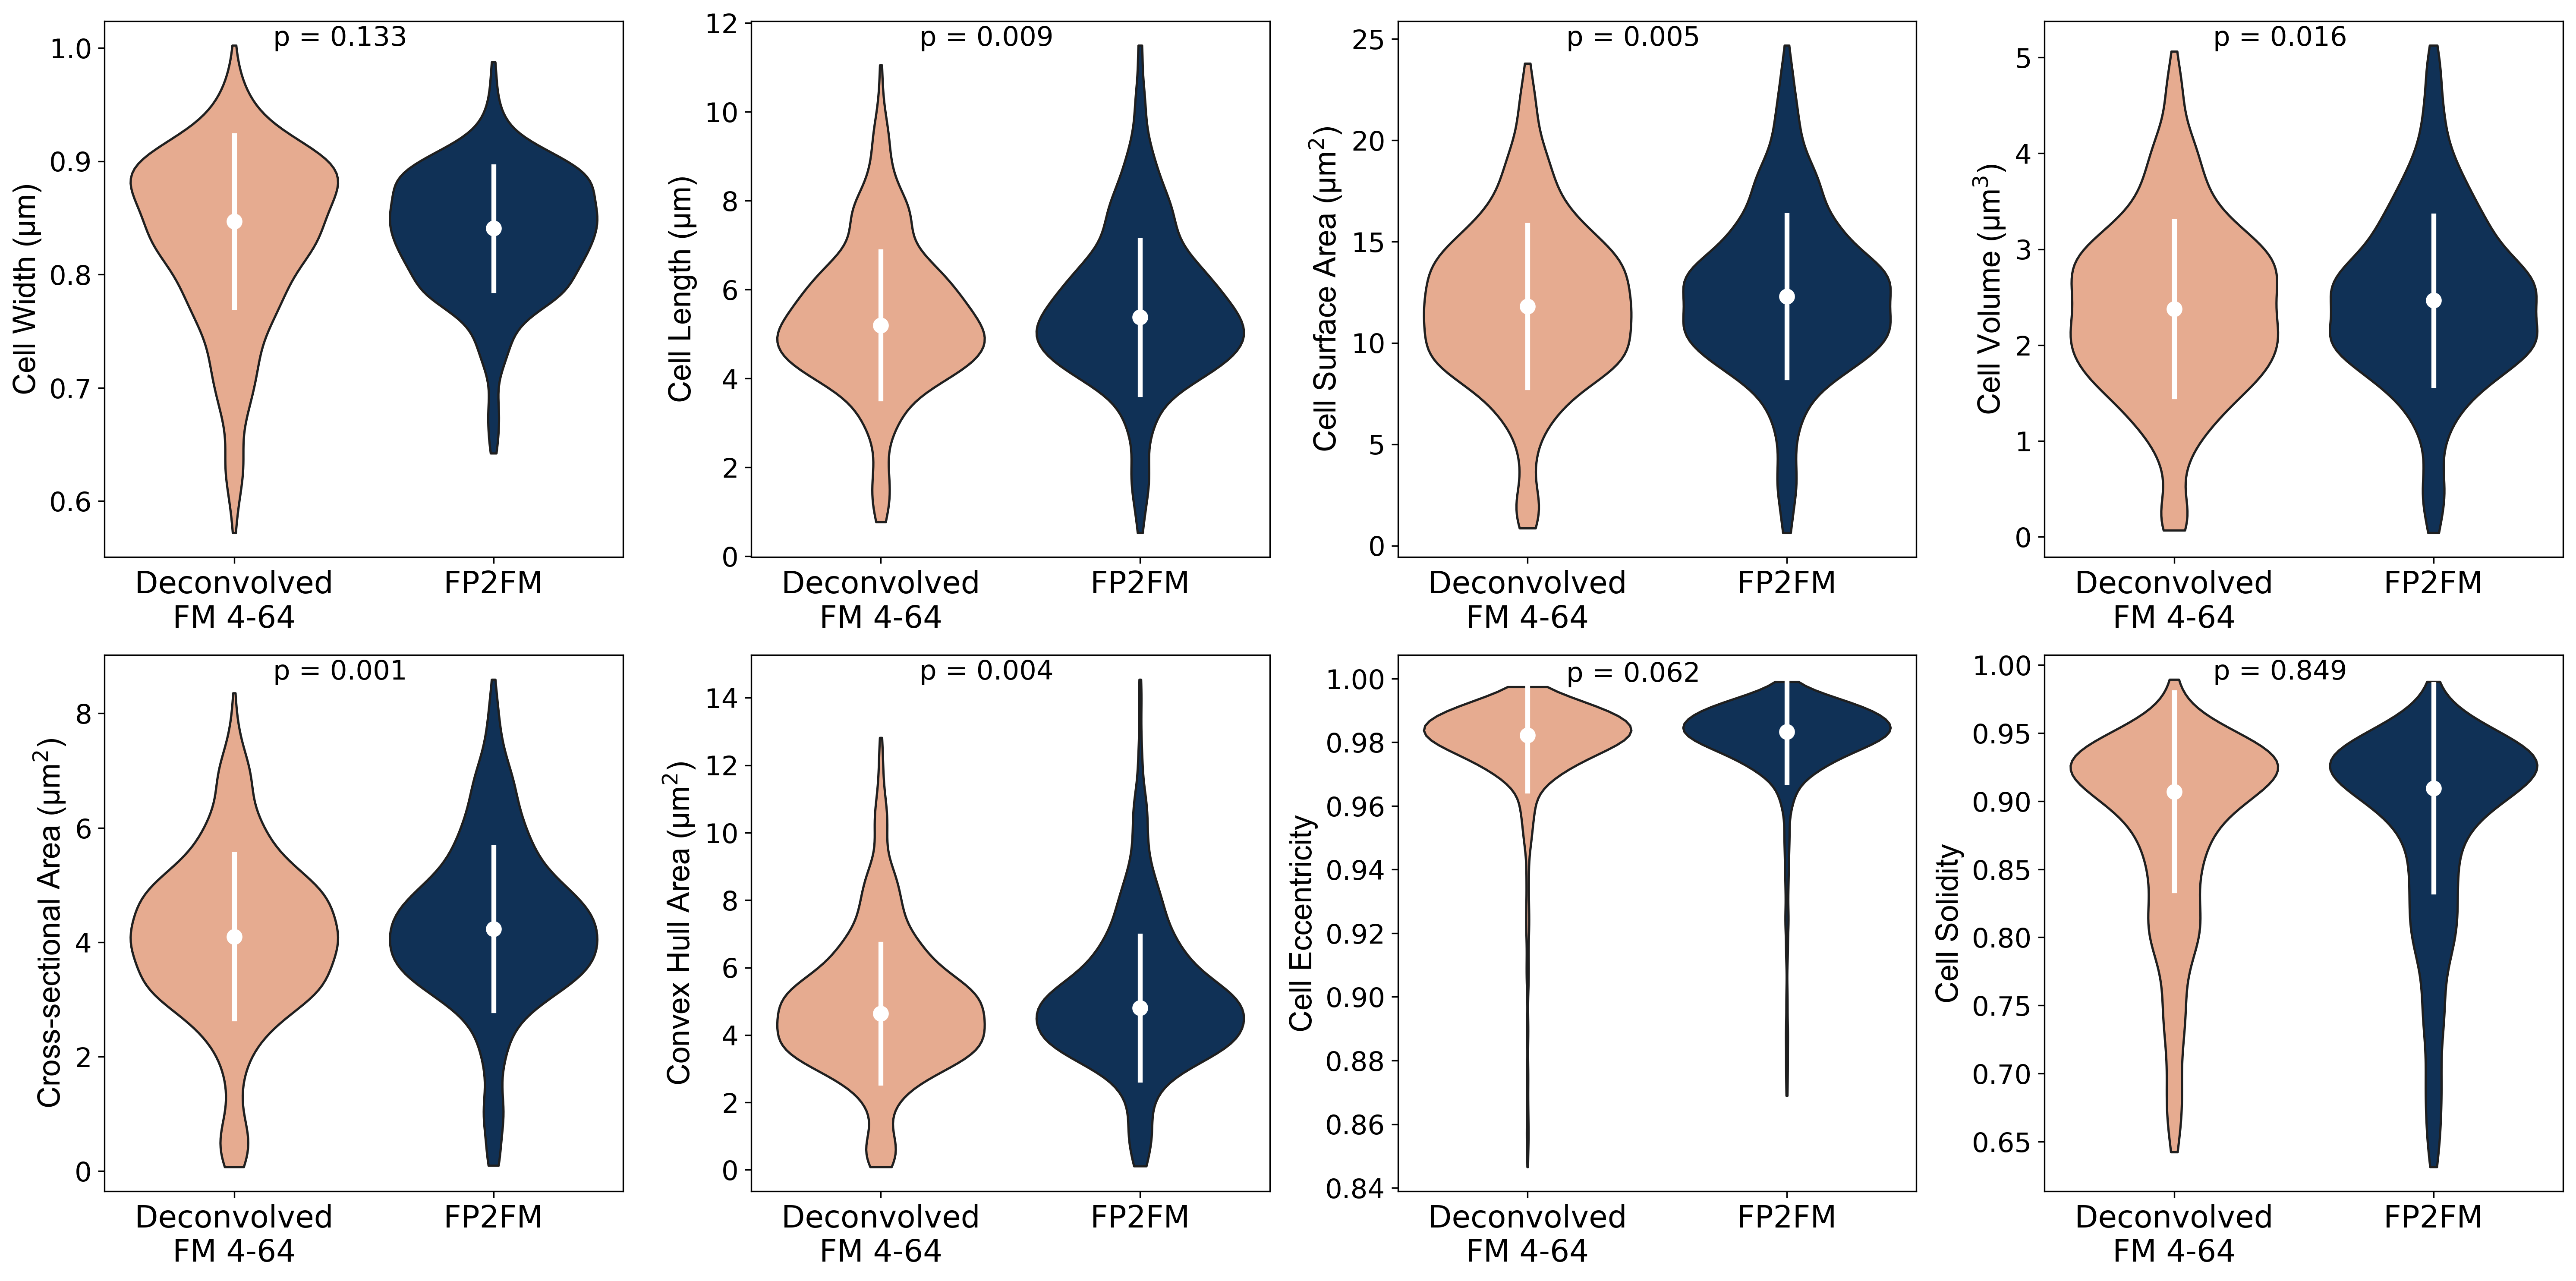

In [35]:
fig,ax = plt.subplots(dpi=300,figsize=(20,10),ncols=4,nrows=2)
ax = ax.flatten()

labels = [f'Deconvolved\nFM 4-64','FP2FM']

for i,subdf in enumerate(sampled_dfs):

    metric = metrics[i]

    vals = []
    
    fp2fm = np.array(subdf[subdf['Method'] == 'FP2FM'][metric])
    softworx = np.array(subdf[subdf['Method'] == 'SoftWorx'][metric])

    if levene(fp2fm,softworx)[1] > 0.05:
        pval = f_oneway(fp2fm,softworx)[1]
    else:
        pval = kruskal(fp2fm,softworx)[1]
    ### Prepare axis label and title

    if metric == 'SurfaceArea':
        ylab = 'Cell Surface Area (µm$^2$)'
        
    elif metric == 'Volume':
        ylab = 'Cell Volume (µm$^3$)'

    elif metric == 'Width':
        ylab = f'Cell {metric} (µm)'

    elif metric == 'Length':
        ylab = f'Cell {metric} (µm)'

    elif metric == 'area':
        ylab = 'Cross-sectional Area (µm$^2$)'
        
    elif metric == 'area_convex':
        ylab = 'Convex Hull Area (µm$^2$)'

    else:
        ylab = f'Cell {metric.capitalize()}'
    
    sns.violinplot(data=subdf,x='Method',y=metric,ax=ax[i],order=['SoftWorx', 'FP2FM'],hue='Method',cut=0,inner=None,palette=colors,density_norm='area')
    sns.pointplot(data=subdf,x='Method',y=metric,ax=ax[i],order=['SoftWorx', 'FP2FM'],linestyle='none',color='w',errorbar='sd',estimator='median')
    ax[i].text(0.15,np.max(subdf[metric]),f'p = {pval:.3f}',fontsize=15)
    
    ax[i].set_xticklabels(labels,fontsize=17)
    ax[i].set_ylabel(ylab,fontname='Arial',fontsize=17)
    ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=15)
    ax[i].set_xlabel('')
    
fig.tight_layout()